## Grid-based Sorting for Colors and Images with ShuffleSoftSort 
This notebook demonstrates the Gradient-based Sorting (ShuffleSoftSort)from the paper:
<div style="text-align: center"> 
<H3>"Permutation Learning with Only N Parameters: <br> From SoftSort to Self-Organizing Gaussians"</H3>
<p style='text-align: center;'> Kai Barthel, Florian Tim Barthel, Peter Eisert 
    <br>
 Visual Computing Group HTW Berlin and Fraunhofer HHI</p>
<br>
<p>
This notebook reads an image with the colors of the pixels (serving as a corlor set) or reads a folder with images and then sorts the colors or the images by similarity. 
    
To measure the quality of a vector sorting, we use a **scale-invariant metric** that compares the average squared distance between neighboring vectors in the sorted grid to the average squared distance of the entire dataset. A value of **1** means the grid is as random as the original data, and a smaller value indicates better sorting. For a more precise measure, the **Distance Preservation Quality (DPQ)** can be used, with a value of **1** represents a perfect and **0** a random sorting.
    
To run this notebook, you need to unzip the included data.zip file. <br>For this notebook, the number of images to be sorted needs to be a square number.

 ## 1. Configuration & Setup

In [10]:
# imports
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image
from dataclasses import dataclass, field
from typing import Tuple, Optional

# notebook settings
np.set_printoptions(edgeitems=11,infstr='inf', linewidth=150, nanstr='nan', precision=3, suppress=True, threshold=20, formatter=None)
torch.set_printoptions(precision=2, threshold=None, edgeitems=10, linewidth=150, profile=None, sci_mode=None)
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [11]:
@dataclass
class Config:
    """Configuration settings for the sorting experiment."""
    # --- Data Sets: choose from image sets: "signs", "kitchen", "web" 
    #             or color sets: "colors_256_random.png", "colors_1024_random.png"
    data_set: str = "kitchen" # "signs" # "colors_1024_random.png" 
    data_path: str = "../data/"
    sort_images: bool = False  # distinguish color & image sorting (no need to change this)
    use_paper_feature_vectors = True  # use the feature vectors from the paper 
                                      # or 4x4x3(RGB) thumbnails as feature vectors
    nx, ny = 0, 0  # Grid size (will be set in load_data)
    
    # --- Model & Training Settings ---
    seed: int = 1 # 7
    shuffle_input: bool = True  # shuffle the initial order of the data set
    learning_rate: float = 0.3
    iterations: int = 4  # Min SoftSort iterations per run
    runs: int = 2000     # Total number of sorting runs (the more, the better the sorting will be)

    # --- Loss Weights ---
    l_constraint: float = 10  # Weight for permutation matrix constraint
    l_std: float = 2         # Weight for standard deviation loss (1 colors, 2

    # --- Tau (Softmax Temperature) Annealing ---
    tau_start: float = 1
    tau_end: float = 0.1
    tau_pow: float = 1.0  # Annealing curve power

    # --- Logging & Visualization ---
    log_every: int = 100  # How often to print logs

    # --- Device ---
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))


### 2: Data Loading

In [12]:
''' Generates feature vectors from small thumbnail images '''
def create_vectors_from_thumbnails(image_files, thumb_size=4):
    
    n_images = len(image_files)   
    feature_vectors = np.zeros((n_images, thumb_size*thumb_size*3))

    for i in range(n_images):
        file = image_files[i]
        im = Image.open(file)
        im.thumbnail((thumb_size, thumb_size), Image.Resampling.BOX)
        pixels = np.array(im) / 255
        pixels = pixels.reshape((thumb_size * thumb_size * 3))
        feature_vectors[i] = pixels
            
    return feature_vectors

In [13]:
def load_data(cfg: Config) -> Tuple[torch.Tensor, Optional[np.ndarray]]:
    """
    Loads data either from a single image or a directory of feature vectors.

    Args:
        cfg: The configuration object.

    Returns:
        A tuple containing:
        - A tensor of vectors (either RGB colors or feature vectors).
        - An array of image file paths (or None).
    """
    set_global_seed(cfg.seed)

    if ".png" in cfg.data_set:
        # Case 1: Load pixel colors from a single image file
        image_path = Path(cfg.data_path) / cfg.data_set
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        vectors = np.array(image.getdata()).reshape((-1, 3)).astype(np.float32)
        image_files = None
        print(f"Loaded {width * height} color vectors from '{image_path}'.")

    else:
        # Case 2: Load feature vectors from a directory
        cfg.sort_images = True
        set_folder = Path(cfg.data_path) / cfg.data_set
        image_files = sorted([str(f) for f in set_folder.rglob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
        image_files = np.array(image_files)

        if cfg.use_paper_feature_vectors:
            vector_dir = set_folder / "vectors"
            vectors = np.array([np.load(vector_dir / f"{Path(f).stem}.npy") for f in image_files]).astype(np.float32)
            print(f"Loaded feature vectors from '{set_folder}'.")
        else:
            vectors = create_vectors_from_thumbnails(image_files, thumb_size=4).astype(np.float32)
        
        n = vectors.shape[0]
        height = width = int(n ** 0.5)
        if height * width != n:
            raise ValueError("Only image sets with a square number of images are supported.")

    if cfg.shuffle_input:
        np.random.shuffle(vectors)  # shuffle the order of the vectors
        if cfg.sort_images:
            set_global_seed(cfg.seed)
            np.random.shuffle(image_files) # shuffle the images the same way
            
    cfg.ny, cfg.nx = height, width

    return torch.from_numpy(vectors), image_files

## 3: The SoftSort Network

In [14]:
class SoftSortNetwork(nn.Module):
    """A network that learns a permutation using a differentiable soft sort."""

    def __init__(self, n: int):
        super().__init__()
        # The learnable weights that determine the sorting order.
        self.weights = nn.Parameter(torch.arange(0., n, dtype=torch.float32))

    def forward(self, tau: float = 1.0) -> torch.Tensor:
        """
        Calculates a differentiable permutation matrix P_hat.

        Args:
            tau: The temperature for the softmax function. Lower tau -> harder permutation.

        Returns:
            An (n, n) differentiable permutation matrix.
        """
        w_col = self.weights.view(-1, 1)
        w_sorted_row = w_col.sort(dim=0)[0].t()

        # Pairwise differences create the sorting cost matrix.
        pairwise_diff = -(w_col - w_sorted_row).abs() / tau

        # Softmax produces the differentiable permutation matrix.
        P_hat = pairwise_diff.softmax(dim=-1)
        return P_hat

## 4: Loss Functions

In [15]:
def get_mean_neighbor_dist(vectors: torch.Tensor, ny: int, nx: int) -> torch.Tensor:
    """
    Calculates the mean squared p-norm distance between adjacent items in a 2D grid.
    """
    grid = vectors.view(ny, nx, -1)

    # Horizontal differences: subtract all elements from their right neighbors
    diff_h = grid[:, :-1, :] - grid[:, 1:, :]
    # Vertical differences: subtract all elements from their bottom neighbors
    diff_v = grid[:-1, :, :] - grid[1:, :, :]

    # Calculate the sum of squared norms for both sets of differences
    sum_sq_h = torch.sum(diff_h ** 2)
    sum_sq_v = torch.sum(diff_v ** 2)

    # The result is the total sum of squared distances divided by the total number of pairs
    num_pairs = (nx - 1) * ny + (ny - 1) * nx

    return (sum_sq_h + sum_sq_v) / num_pairs

# ------------------------------------------------------------------------------

def permutation_constraint_loss(perm_matrix: torch.Tensor) -> torch.Tensor:
    """Enforces the doubly stochastic property of the permutation matrix."""
    return torch.mean((perm_matrix.sum(dim=0) - 1) ** 2) # + \
       # torch.mean((perm_matrix.sum(dim=1) - 1) ** 2)

# ------------------------------------------------------------------------------

def calculate_total_loss(
        perm_soft: torch.Tensor,
        x_sort_soft: torch.Tensor,
        expected_stats: dict,
        cfg: Config
) -> dict:
    """Calculates and returns all components of the loss."""
    loss_neighbors = get_mean_neighbor_dist(x_sort_soft, cfg.ny, cfg.nx) / expected_stats['mean_dist']
    loss_constraint = cfg.l_constraint * permutation_constraint_loss(perm_soft)

    std_x_sort_soft = torch.std(x_sort_soft, dim=0)
    loss_std = cfg.l_std * torch.abs(expected_stats['std'] - std_x_sort_soft).sum() / expected_stats['std'].sum()

    total = loss_neighbors + loss_std + loss_constraint

    return {'total': total, 'neighbors': loss_neighbors, 'std': loss_std, 'constraint': loss_constraint}


## 5: Helper & Utility Functions

In [16]:
def set_global_seed(seed: int):
    """
    Sets random seed into PyTorch, TensorFlow, Numpy and Random.
    Args:
        seed: random seed
    """
    if seed == -1:
        seed = np.random.randint(2 ** 32)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    random.seed(seed)
    np.random.seed(seed)

    cfg.seed = seed
    
def shuffle_numbers_with_degree(N: int, degree: float, device) -> torch.Tensor:
    """
    Generates a 1D PyTorch tensor containing integers from 0 to N-1,
    shuffled according to the specified degree. Runs efficiently on GPU.

    Args:
        N (int): Length of the array.
        degree (float): Shuffle degree [0.0, 1.0].
        device (str): Torch device ("cuda" for GPU, "cpu" otherwise).

    Returns:
        torch.Tensor: 1D permutation tensor of shape (N,).
    """

    # Base array
    arr = torch.arange(N, device=device, dtype=torch.int64)

    if degree == 0.0:
        return arr

    if degree == 1.0:
        return arr[torch.randperm(N, device=device)]

    # --- Partial shuffle approximation ---
    # Generate random noise, scaled by `degree * N`
    max_shift = degree * (N+1)
    noise = max_shift * torch.rand((N,), device=device)

    # Add noise to indices and re-sort
    perturbed = arr + noise
    _, perm = torch.sort(perturbed)

    return perm
    


def visualize_result(
        sorted_vectors: torch.Tensor,
        ny: int,
        nx: int,
        title: str,
        sorted_files: Optional[np.ndarray] = None
):
    """Creates and displays the sorted image or color swatch."""
    fig = plt.figure(figsize=(6, 6))
    plt.title(title, fontsize=14)
    plt.axis('off')

    if sorted_files is not None:  # Create a collage from image files
        pixels_per_image = 128
        collage = np.zeros((pixels_per_image * ny, pixels_per_image * nx, 3))
        reshaped_files = np.array(sorted_files).reshape((ny, nx))

        for i in range(ny):
            for j in range(nx):
                with Image.open(reshaped_files[i, j]) as im:
                    im.thumbnail((pixels_per_image, pixels_per_image), Image.Resampling.LANCZOS)
                    pixels = np.array(im.convert("RGB")) / 255.0
                    collage[i * pixels_per_image:(i + 1) * pixels_per_image,
                    j * pixels_per_image:(j + 1) * pixels_per_image] = pixels
        plt.imshow(collage)
    else:
        # Show a grid of sorted color vectors
        img = sorted_vectors.detach().cpu().numpy().astype(np.uint8).reshape(ny, nx, -1)
        plt.imshow(img)

    plt.show()


##  6: Main Solver Function

In [17]:
def perform_sorting(
        x: torch.Tensor,
        image_files: Optional[np.ndarray],
        cfg: Config
) -> Tuple[torch.Tensor, np.ndarray]:
    """
    Runs the main ShuffleSoftSort optimization loop.

    Args:
        x: The input tensor of vectors to sort.
        image_files: An optional array of corresponding image file paths.
        cfg: The configuration object.

    Returns:
        A tuple of the final sorted vectors and sorted indices.
    """

    n = x.shape[0]
    x = x.to(cfg.device)
    indices = torch.arange(n, device=cfg.device)
    ny, nx = cfg.ny, cfg.nx

    # Pre-calculate expected statistics of the input data
    var_x = torch.var(x, dim=0, unbiased=True)
    expected_stats = {
        'mean_dist': 2 * var_x.sum(),
        'std': var_x.sqrt()
    }

    for run in range(cfg.runs + 1):
        net = SoftSortNetwork(n).to(cfg.device)
        optimizer = torch.optim.Adam(net.parameters(), lr=cfg.learning_rate)

        # Anneal tau (temperature) over runs
        tau = cfg.tau_start * (cfg.tau_end / cfg.tau_start) ** ((run / cfg.runs) ** cfg.tau_pow)

        # The input vectors are shuffled for each run 
        # shuf_idx = torch.randperm(n, device=cfg.device)        
        degree = 0.33 * (1 - run / cfg.runs) + 0.1
        shuf_idx = shuffle_numbers_with_degree(n, degree, cfg.device).to(cfg.device)

        # For square images, optionally transpose the shuffle grid to break symmetries
        if ny == nx and run % 2 == 0:
            shuf_y, shuf_x =  shuf_idx // nx, shuf_idx % nx
            shuf_idx = (shuf_x * nx + shuf_y).reshape(nx, ny).T.flatten()

        x_shuf = x[shuf_idx]
        indices_shuf = indices[shuf_idx]

        it = 0
        while True:
            it += 1
            optimizer.zero_grad()

            perm_soft = net(tau)
            x_sort_soft = perm_soft @ x_shuf

            # Un-shuffle so the loss can be computed on the original, unshuffled layout.
            x_sort_soft_unshuffled = x_sort_soft.clone()
            x_sort_soft_unshuffled[shuf_idx] = x_sort_soft

            losses = calculate_total_loss(perm_soft, x_sort_soft_unshuffled, expected_stats, cfg)
            losses['total'].backward()
            optimizer.step()

            sort_idx = torch.argmax(perm_soft, dim=-1)
            num_duplicates = n - torch.unique(sort_idx).shape[0]

            # Termination condition for the inner loop
            if num_duplicates == 0 and it >= cfg.iterations:
                indices[shuf_idx] = indices_shuf[sort_idx]
                x[shuf_idx] = x_shuf[sort_idx]

                if run % cfg.log_every == 0:
                    hard_dist = get_mean_neighbor_dist(x, ny, nx) / expected_stats['mean_dist']
                    # hard_dist = get_mean_neighbor_dist(x, ny, nx) / expected_stats['mean_dist']
                    print(
                        f"Run: {run:4d} | τ: {tau:.3f} | "
                        f"L: {losses['total']:.3f} (nbr: {losses['neighbors']:.3f}, std: {losses['std']:.3f}, cons: {losses['constraint']:.3f}) | "
                        f" Dist ratio: {hard_dist:.3f}"
                    )
                break

    return x, indices

## 7. Main Execution Block

Starting experiment on device: cpu with seed: 1
Loaded feature vectors from '../data/kitchen'.


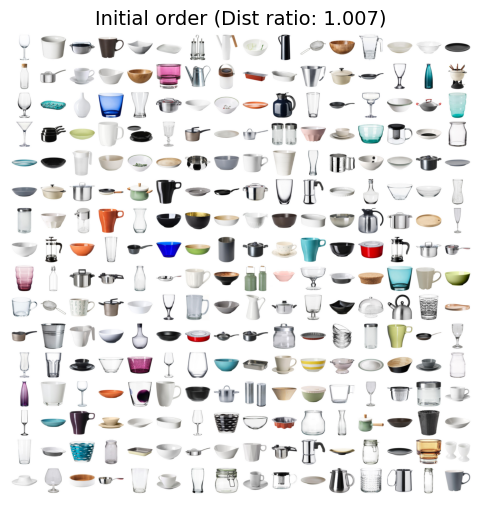


--- Starting Optimization ---
Run:    0 | τ: 1.000 | L: 1.180 (nbr: 0.300, std: 0.870, cons: 0.010) |  Dist ratio: 0.967
Run:  100 | τ: 0.891 | L: 1.091 (nbr: 0.289, std: 0.787, cons: 0.015) |  Dist ratio: 0.824
Run:  200 | τ: 0.794 | L: 0.963 (nbr: 0.313, std: 0.635, cons: 0.015) |  Dist ratio: 0.734
Run:  300 | τ: 0.708 | L: 0.902 (nbr: 0.298, std: 0.587, cons: 0.018) |  Dist ratio: 0.668
Run:  400 | τ: 0.631 | L: 0.821 (nbr: 0.318, std: 0.487, cons: 0.016) |  Dist ratio: 0.629
Run:  500 | τ: 0.562 | L: 0.746 (nbr: 0.307, std: 0.427, cons: 0.011) |  Dist ratio: 0.569
Run:  600 | τ: 0.501 | L: 0.655 (nbr: 0.313, std: 0.333, cons: 0.009) |  Dist ratio: 0.525
Run:  700 | τ: 0.447 | L: 0.629 (nbr: 0.330, std: 0.294, cons: 0.005) |  Dist ratio: 0.504
Run:  800 | τ: 0.398 | L: 0.579 (nbr: 0.337, std: 0.238, cons: 0.004) |  Dist ratio: 0.483
Run:  900 | τ: 0.355 | L: 0.507 (nbr: 0.326, std: 0.179, cons: 0.003) |  Dist ratio: 0.442
Run: 1000 | τ: 0.316 | L: 0.469 (nbr: 0.324, std: 0.142, co

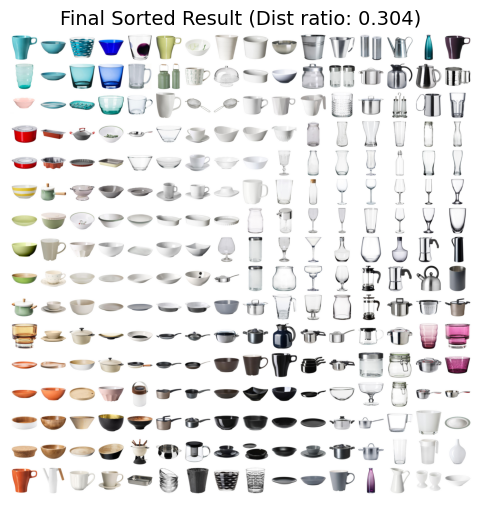

In [18]:
# --- 1. Setup ---
cfg = Config()
print(f"Starting experiment on device: {cfg.device} with seed: {cfg.seed}")

# --- 2. Load Data ---
vectors, image_files = load_data(cfg)

initial_dist = get_mean_neighbor_dist(vectors, cfg.ny, cfg.nx) / (2 * torch.var(vectors, dim=0).sum())

visualize_result(
    vectors, cfg.ny, cfg.nx,
    title=f"Initial order (Dist ratio: {initial_dist:.3f})",
    sorted_files=image_files
)

# --- 3. Run Solver ---
print("\n--- Starting Optimization ---")
start_time = time.time()
sorted_vectors, sorted_indices = perform_sorting(vectors, image_files, cfg)
duration = time.time() - start_time
print(f"--- Finished in {duration:.2f} seconds ---")

# --- 4. Display Final Result ---
final_files = image_files[sorted_indices] if cfg.sort_images else None

final_dist = get_mean_neighbor_dist(sorted_vectors, cfg.ny, cfg.nx) / (2 * torch.var(vectors, dim=0).sum())

visualize_result(
    sorted_vectors, cfg.ny, cfg.nx,
    title=f"Final Sorted Result (Dist ratio: {final_dist:.3f})",
    sorted_files=final_files
)